# Last Modified: 2026-04-23 15:00:00

---

# LFP Battery SOH Preprocessing Pipeline (Universal Version)

This notebook implements a physically-consistent preprocessing framework for multi-source battery datasets:
1. **Phase 0**: Data Loading (HUST, MIT-Stanford, etc.)
2. **Phase 0-1**: MIT Data Adapter (Port to HUST DataFrame Format)
3. **Phase 0.5**: Dataset-agnostic Configuration & Helpers
4. **Phase 1**: Global Physical Cleaning (Savitzky-Golay Smoothing & Outlier Removal)
5. **Phase 2**: Scenario-based Slicing Definition
6. **Phase 2.1**: **Global Slicing Loop (Generate & Cache Raw Segment Pool with RUL/Cap labels)**
7. **Phase 3**: 45D Adaptive HI Extraction Logic (Standardized V/I/T/Q features)
8. **Phase 4**: **Feature Extraction & Batch Scaling**
9. **Phase 5**: Global Tensor Saving (Optimized pkl tensors on D: drive)
10. **Phase 6**: Dataset-wide Visualization & PCA Analysis

In [2]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from tqdm.notebook import tqdm
import os
import sys
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
from scipy.signal import savgol_filter
from collections import defaultdict

# Add project root to sys.path
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Set processed data storage path (D drive for large files)
PROCESSED_DATA_ROOT = Path("D:/chanminLee/data_store/LFP_SOH_estimation")
PROCESSED_DATA_ROOT.mkdir(parents=True, exist_ok=True)

from src.data.loaders import load_hust, load_mit

## Phase 0.5: Dataset-agnostic Configuration & Helpers

In [5]:
# Define standardized column constants for internal logic
COL_V = "Voltage (V)"
COL_I = "Current (A)"
COL_T = "Temperature (°C)"
COL_TIME = "Time (s)"

def get_cell_labels(cell, cyc, dataset_type):
    """Extract RUL and SOH (Capacity) labels in a dataset-agnostic way."""
    if dataset_type == "hust":
        return cell.rul[cyc], cell.dq[cyc]
    elif dataset_type == "mit":
        rul = None
        if cell.cycle_life is None: 
            rul = 0
        else:
            rul = cell.cycle_life - cyc
        cap = cell.summary['QD'][cyc-1] if (cyc-1) < len(cell.summary['QD']) else 0.0
        return float(rul), float(cap)
    return 0.0, 0.0

def get_batch_id(cid, dataset_type):
    """Standardize batch identification for grouping chunks."""
    if dataset_type == "hust":
        return str(cid).split("-")[0]
    elif dataset_type == "mit":
        return str(cid).split("c")[0]
    return "batch_0"

## Phase 0: Data Loading

In [6]:
DATASET_TYPE = "hust" # Switch to "hust" or "mit" as needed

if DATASET_TYPE == "hust":
    print("Loading HUST dataset...")
    all_cells = load_hust(PROJECT_ROOT / "HUST_data" / "data")
elif DATASET_TYPE == "mit":
    print("Loading MIT-Stanford dataset...")
    all_cells = load_mit(PROJECT_ROOT / "MIT_data")
print(f"Loaded {len(all_cells)} cells for {DATASET_TYPE.upper()} dataset.")

Loading HUST dataset...


HUST Cells:   0%|          | 0/77 [00:00<?, ?it/s]

HUST Cells: 100%|██████████| 77/77 [01:02<00:00,  1.24it/s]

Loaded 77 cells for HUST dataset.


## Phase 0-1: MIT Data Adapter (HUST DataFrame Format)

In [6]:
# Phase 0-1: Porting MIT data to HUST format (Pandas DataFrame)
if DATASET_TYPE == "mit":
    print("Porting MIT data to HUST format (Pandas DataFrame)...")
    for cid, cell in tqdm(all_cells.items(), desc="Converting MIT to DataFrame"):
        # Create .data dictionary to mimic HUST structure
        cell.data = {}
        for cyc_key, cyc_dict in cell.cycles.items():
            if int(cyc_key) > 0:  # Skip 0th cycle
                # Match internal column conventions
                df = pd.DataFrame({
                    COL_TIME: cyc_dict['t'],
                    COL_V: cyc_dict['V'],
                    COL_I: cyc_dict['I'], # MIT uses A natively
                    COL_T: cyc_dict['T']
                })
                cell.data[int(cyc_key)] = df

## Phase 1: Global Physical Cleaning & Unit Conversion

In [7]:
CLEAN_CACHE_DIR = PROCESSED_DATA_ROOT / f" {DATASET_TYPE}_clean_chunks"
CLEAN_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_REPORT_PATH = PROJECT_ROOT / "outputs" / "cleaning_report.csv"

In [10]:
def clean_physical_data(df, cid, cyc, cleaning_reports):
    clean_df = df.copy()
    if "Current (mA)" in clean_df.columns:
        clean_df[COL_I] = clean_df["Current (mA)"] / 1000.0
    
    num_cols = clean_df.select_dtypes(include=[np.number]).columns
    outlier_mask = pd.Series(False, index=clean_df.index)
    detail_records = {}
    for col in num_cols:
        if col == 'COL_V' and DATASET_TYPE == "hust":
            continue
        details = {'outlier_info': [], 'nan_info': []}
        nan_mask = clean_df[col].isna()
        if nan_mask.any():
            details['nan_info'] = clean_df.index[nan_mask].tolist()
        col_std = clean_df[col].std()
        if col_std > 1e-6:
            z_scores = np.abs((clean_df[col] - clean_df[col].mean()) / col_std)
            is_outlier = z_scores >= 7
            if is_outlier.any():
                outlier_mask |= is_outlier
                outlier_indices = clean_df.index[is_outlier].tolist()
                outlier_values = clean_df.loc[is_outlier, col].tolist()
                details['outlier_info'] = [(idx, round(val, 4)) for idx, val in zip(outlier_indices, outlier_values)]
        detail_records[col] = details
    if outlier_mask.any():
        clean_df = clean_df[~outlier_mask].copy()
    if not clean_df.empty:
        for col in num_cols:
            det = detail_records[col]
            o_count = len(det['outlier_info'])
            nan_count = len(det['nan_info'])
            if o_count > 0 or nan_count > 0:
                cleaning_reports.append({
                    "cell_id": cid, "cycle": cyc, "feature": col,
                    "outlier_removed": o_count, "interpolated_count": nan_count,
                    "outlier_details_(idx,val)": str(det['outlier_info']) if o_count > 0 else "",
                    "nan_indices": str(det['nan_info']) if nan_count > 0 else ""
                })
        clean_df[num_cols] = clean_df[num_cols].interpolate(method='linear', limit_direction='both')
        clean_df = clean_df.ffill().bfill()
        
        if COL_V in clean_df.columns and len(clean_df) >= 11:
            clean_df[COL_V] = savgol_filter(clean_df[COL_V], window_length=11, polyorder=3)
    return clean_df

batch_groups = defaultdict(dict)
for cid, cell in all_cells.items():
    b_id = get_batch_id(cid, DATASET_TYPE)
    batch_groups[b_id][cid] = cell
all_cleaning_reports = []
for batch_id in sorted(batch_groups.keys()):
    batch_cache_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}.pkl"
    if batch_cache_path.exists():
        report_part_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}_report.pkl"
        if report_part_path.exists():
            with open(report_part_path, "rb") as f:
                all_cleaning_reports.extend(pickle.load(f))
        continue
    batch_cells = batch_groups[batch_id]
    batch_cleaned = {}
    batch_reports = []
    for cid, cell in batch_cells.items():
        batch_cleaned[cid] = {}
        for cyc in tqdm(list(cell.data.keys()), desc=f"  Cleaning Cell {cid}"):
            batch_cleaned[cid][cyc] = clean_physical_data(cell.data[cyc], cid, cyc, batch_reports)
    with open(batch_cache_path, "wb") as f:
        pickle.dump(batch_cleaned, f, protocol=pickle.HIGHEST_PROTOCOL)
    report_part_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}_report.pkl"
    with open(report_part_path, "wb") as f:
        pickle.dump(batch_reports, f, protocol=pickle.HIGHEST_PROTOCOL)
    all_cleaning_reports.extend(batch_reports)
    del batch_cleaned, batch_reports
    gc.collect()
report_df = pd.DataFrame(all_cleaning_reports)
report_df.to_csv(CLEAN_REPORT_PATH, index=False)
print(f"Cleaning report saved to {CLEAN_REPORT_PATH}")

Cleaning report saved to c:\Users\ksshin\Desktop\ChanminLee\LFP_SOH_prediction\outputs\cleaning_report.csv


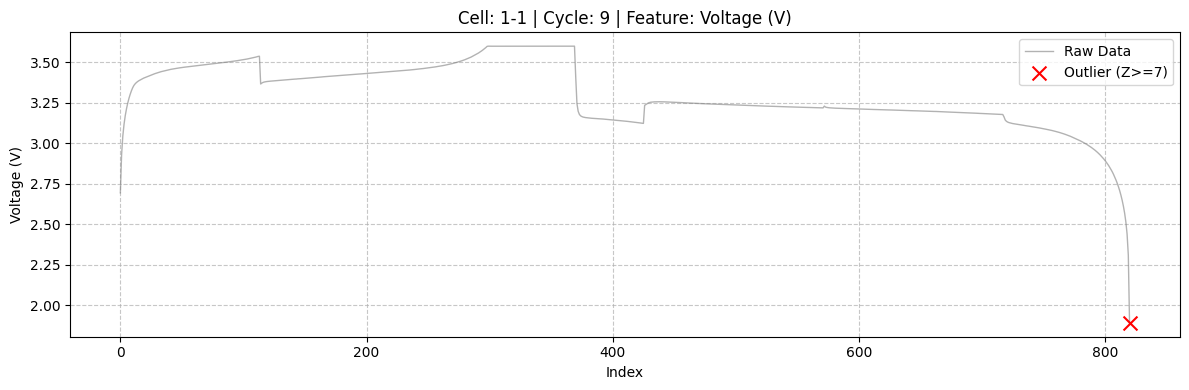

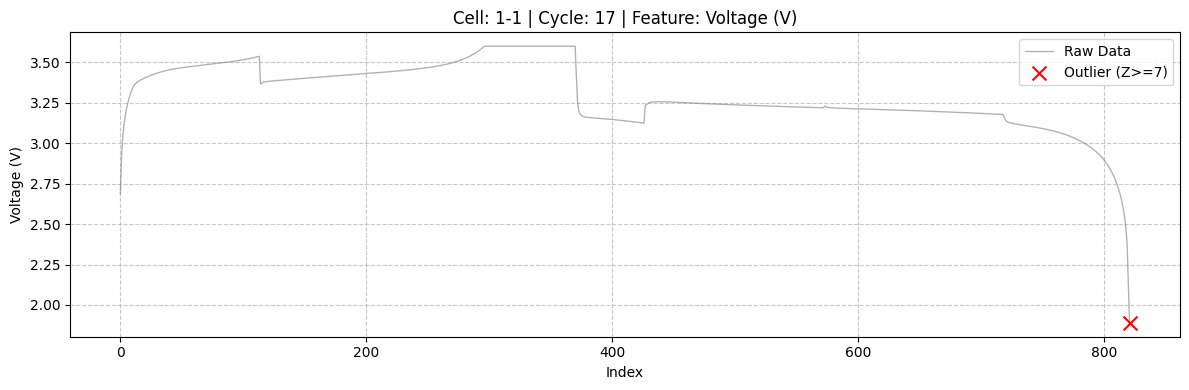

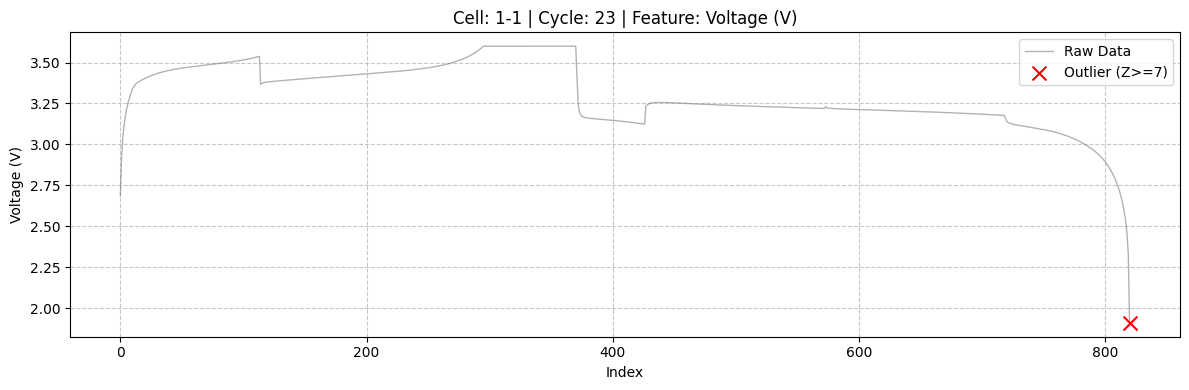

In [11]:
import matplotlib.pyplot as plt

def plot_data_cleaning_issues(all_cells, report_df, num_samples=5):
    """
    이상치나 결측치가 보고된 셀/사이클 데이터를 시각화합니다.
    """
    if report_df.empty:
        print("보고된 이상치/결측치가 없습니다.")
        return

    # 유니크한 (cell_id, cycle) 조합 중 상위 n개 선택
    samples = report_df[['cell_id', 'cycle']].drop_duplicates().head(num_samples)
    
    for _, row in samples.iterrows():
        cid = row['cell_id']
        cyc = row['cycle']

        # 해당 셀과 사이클의 원본 데이터 가져오기
        if cid not in all_cells or cyc not in all_cells[cid].data:
            continue

        raw_df = all_cells[cid].data[cyc].copy()

        # mA -> A 변환 (원본 데이터가 mA인 경우 대비)
        if "Current (mA)" in raw_df.columns and COL_I not in raw_df.columns:
            raw_df[COL_I] = raw_df["Current (mA)"] / 1000.0

        # 해당 (cid, cyc)에 대해 보고된 모든 피처들 확인
        issues = report_df[(report_df['cell_id'] == cid) & (report_df['cycle'] == cyc)]

        fig, axes = plt.subplots(len(issues), 1, figsize=(12, 4 * len(issues)), sharex=True)
        if len(issues) == 1:
            axes = [axes]

        for ax, (_, issue) in zip(axes, issues.iterrows()):
            col = issue['feature']

            # 1. 전체 데이터 플롯
            ax.plot(raw_df.index, raw_df[col], label='Raw Data', color='gray', alpha=0.6, linewidth=1)

            # 2. 결측치(NaN) 위치 표시
            nan_indices = raw_df.index[raw_df[col].isna()]
            if not nan_indices.empty:
                ax.scatter(
                    nan_indices,
                    [raw_df[col].mean()] * len(nan_indices),
                    marker='x',
                    color='blue',
                    s=100,
                    label='NaN (Missing)',
                    zorder=5
                )

            # 3. 이상치(Outlier) 위치 표시
            col_std = raw_df[col].std()
            if col_std > 1e-6:
                z_scores = np.abs((raw_df[col] - raw_df[col].mean()) / col_std)
                outlier_mask = z_scores >= 7
                outlier_indices = raw_df.index[outlier_mask]

                if not outlier_indices.empty:
                    ax.scatter(
                        outlier_indices,
                        raw_df.loc[outlier_mask, col],
                        marker='x',
                        color='red',
                        s=100,
                        label='Outlier (Z>=7)',
                        zorder=6
                    )

            ax.set_title(f"Cell: {cid} | Cycle: {cyc} | Feature: {col}")
            # ax.set_xlabel(f"Index": {})
            ax.set_ylabel(col)
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.7)

        plt.xlabel("Index")
        plt.tight_layout()
        plt.show()

# 사용 예시:
report_df = pd.read_csv(CLEAN_REPORT_PATH)
plot_data_cleaning_issues(all_cells, report_df, num_samples=3)

## Phase 2: Scenario-based Slicing Definition

In [12]:
def phase2_slice_data(df, start_p=0.0, end_p=1.0, mode="C"): 
    col_i = COL_I if COL_I in df.columns else [c for c in df.columns if "Current" in c][0]
    mode_df = df[df[col_i] > 0.01] if mode == "C" else df[df[col_i] < -0.01]
    if mode_df.empty: return mode_df, 0, (1 if mode == "C" else 0)
    n = len(mode_df)
    s_idx, e_idx = int(n * start_p), int(n * end_p)
    sliced = mode_df.iloc[s_idx:e_idx]
    avg_pos = (start_p + end_p) / 2
    soc_label = -2 if avg_pos <= 0.3 else (-1 if avg_pos <= 0.7 else 0)
    mode_label = 1 if mode == "C" else 0
    return sliced, soc_label, mode_label

## Phase 2.1: Global Slicing Loop

In [13]:
CACHE_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_sliced_chunks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
scen_bounds = {"H": (0.0, 0.3), "M": (0.3, 0.7), "L": (0.7, 1.0)}
lengths = [0.1, 0.2, 0.3]
step = 0.1
all_raw_segments = []
batch_groups = defaultdict(dict)
for cid, cell in all_cells.items():
    b_id = get_batch_id(cid, DATASET_TYPE)
    batch_groups[b_id][cid] = cell

for batch_id in tqdm(sorted(batch_groups.keys())):
    slice_cache_path = CACHE_DIR / f"batch_{batch_id}.pkl"
    clean_cache_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}.pkl"
    if slice_cache_path.exists():
        with open(slice_cache_path, "rb") as f: batch_data = pickle.load(f)
        all_raw_segments.extend(batch_data['segments'])
        continue

    with open(clean_cache_path, "rb") as f: batch_cleaned = pickle.load(f)
    batch_segments = []
    for cid, cell in tqdm(batch_groups[batch_id].items(), desc=f"Processing Batch {batch_id}"):
        cleaned_cycles = batch_cleaned.get(cid, {})
        for cyc in tqdm(sorted(cleaned_cycles.keys()), desc=f"  Slicing Cell {cid}"):
            df = cleaned_cycles[cyc]
            num_cols = df.select_dtypes(include=[np.number]).columns
            df[num_cols] = df[num_cols].astype(np.float32)
            
            rul_label, cap_label = get_cell_labels(cell, cyc, DATASET_TYPE)
            
            for mode in ["C", "D"]:
                for scen_name, (s_bound, e_bound) in scen_bounds.items():
                    for length in lengths:
                        max_start = e_bound - length
                        if max_start < s_bound: continue
                        for start_p in np.arange(s_bound, max_start + 0.0001, step):
                            end_p = start_p + length
                            sliced, soc_l, mode_l = phase2_slice_data(df, start_p, end_p, mode)
                            if not sliced.empty and len(sliced) >= 5:
                                batch_segments.append({
                                    "cell": cid, "cyc": cyc, "df": sliced,
                                    "soc_label": soc_l, "mode_label": mode_l,
                                    "length_p": length,
                                    "rul": rul_label,
                                    "capacity": cap_label,
                                    "cycle_key": (cid, cyc)
                                })

    with open(slice_cache_path, "wb") as f:
        pickle.dump({'segments': batch_segments}, f, protocol=pickle.HIGHEST_PROTOCOL)

    all_raw_segments.extend(batch_segments)
    del batch_cleaned, batch_segments
    gc.collect()
    print(f"Total segments: {len(all_raw_segments)}")

  0%|          | 0/10 [00:00<?, ?it/s]

Processing Batch 1:   0%|          | 0/8 [00:00<?, ?it/s]

  Slicing Cell 1-1:   0%|          | 0/1504 [00:00<?, ?it/s]

  Slicing Cell 1-2:   0%|          | 0/2678 [00:00<?, ?it/s]

  Slicing Cell 1-3:   0%|          | 0/1858 [00:00<?, ?it/s]

...

  Slicing Cell 9-5:   0%|          | 0/2168 [00:00<?, ?it/s]

  Slicing Cell 9-6:   0%|          | 0/1742 [00:00<?, ?it/s]

  Slicing Cell 9-7:   0%|          | 0/2012 [00:00<?, ?it/s]

  Slicing Cell 9-8:   0%|          | 0/2308 [00:00<?, ?it/s]

Total segments: 6137124


## Phase 2.2: Slicing Summary Visualization

=== 📊 Sliced Data Structure Summary ===
Total segments length : 6137124
Single segment type   : <class 'dict'>
Segment Dictionary Keys: ['cell', 'cyc', 'df', 'soc_label', 'mode_label', 'length_p', 'rul', 'capacity', 'cycle_key']
Inner DataFrame shape : (38, 7)
Inner DataFrame columns: ['Status', 'Cycle number', 'Current (mA)', 'Voltage (V)', 'Capacity (mAh)', 'Time (s)', 'Current (A)']



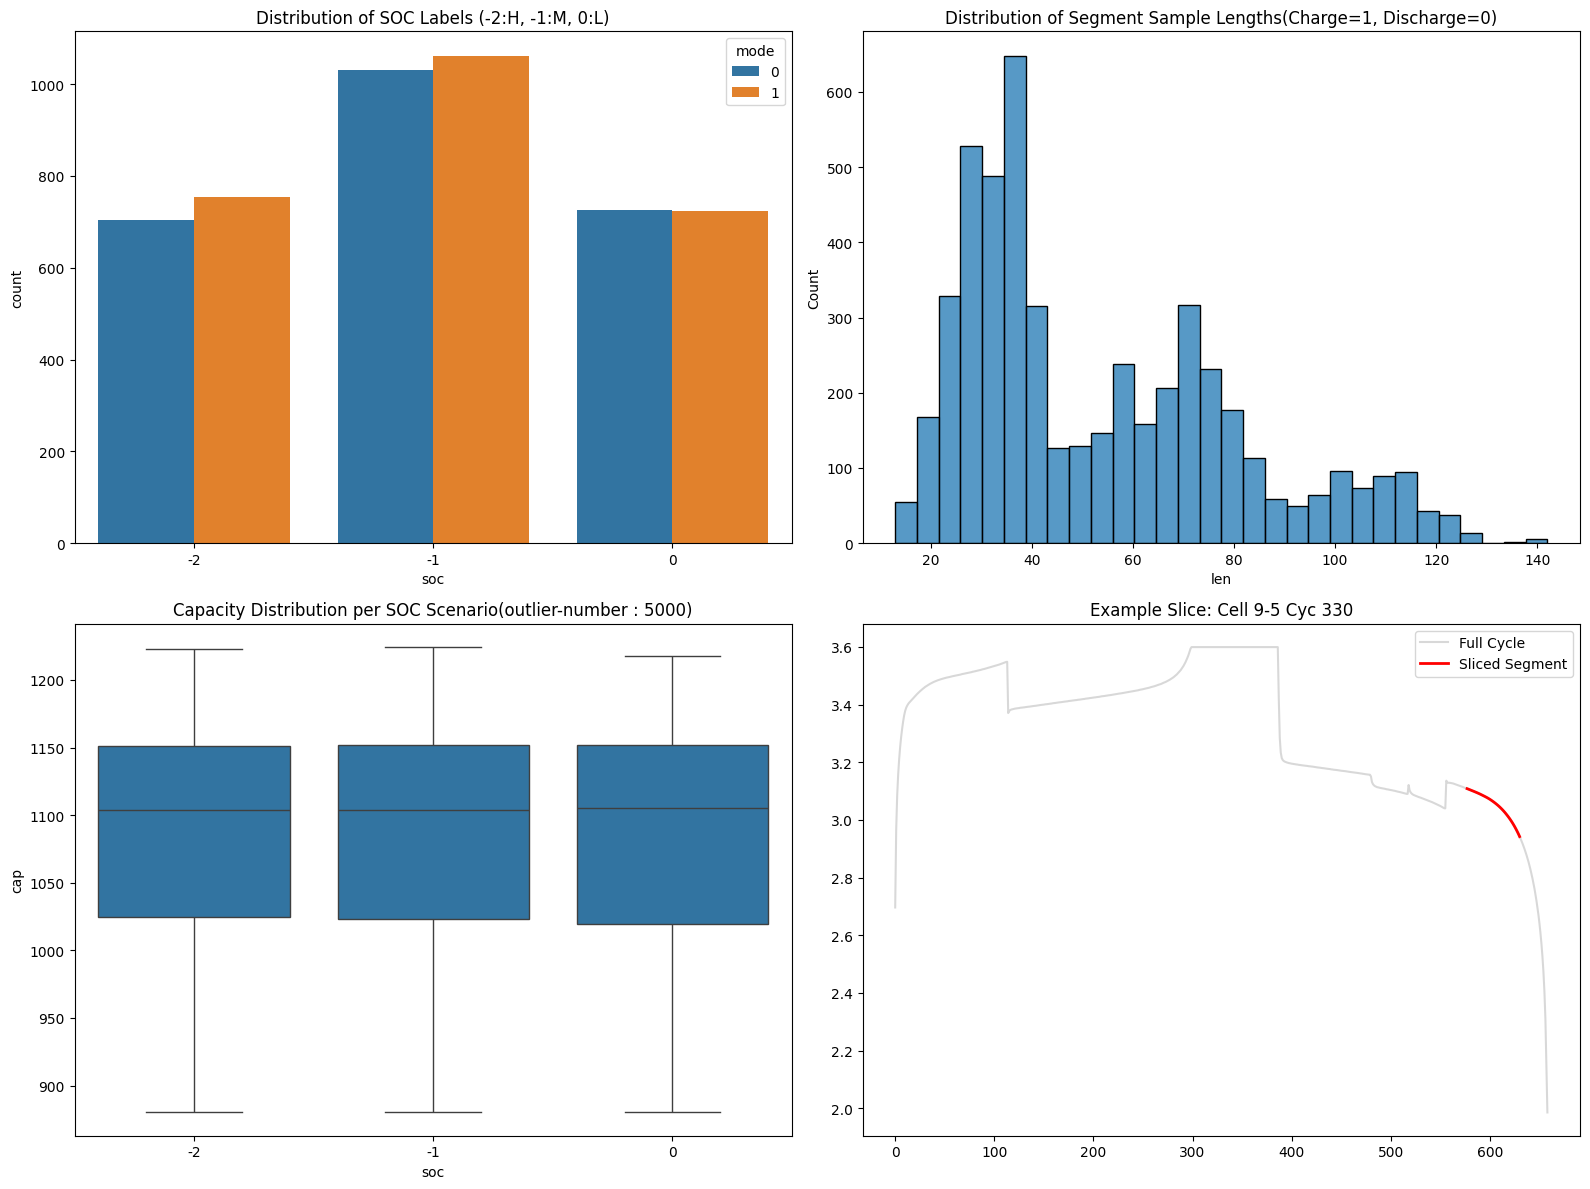

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_phase2_slicing_summary(segments, num_samples=3):
    # --- [추가된 출력문: 슬라이싱 후 데이터 구조 형태 확인] ---
    if segments:
        sample = segments[0]
        print("=== Sliced Data Structure Summary ===")
        print(f"Total segments length : {len(segments)}")
        print(f"Single segment type   : {type(sample)}")
        print(f"Segment Dictionary Keys: {list(sample.keys())}")
        
        if 'df' in sample and isinstance(sample['df'], pd.DataFrame):
            print(f"Inner DataFrame shape : {sample['df'].shape}")
            print(f"Inner DataFrame columns: {list(sample['df'].columns)}")
        print("=========================================\n")
    # ----------------------------------------------------

    # Sample for performance
    sample_idx = np.random.choice(len(segments), min(5000, len(segments)), replace=False)
    df_meta = pd.DataFrame([{
        "soc": segments[i]["soc_label"], 
        "mode": segments[i]["mode_label"], 
        "len": len(segments[i]["df"]), 
        "cap": segments[i]["capacity"]
    } for i in sample_idx])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. SOC Label Distribution
    sns.countplot(data=df_meta, x='soc', hue='mode', ax=axes[0,0])
    axes[0,0].set_title("Distribution of SOC Labels (-2:H, -1:M, 0:L)")
    
    # 2. Segment Length Distribution
    sns.histplot(data=df_meta, x='len', bins=30, ax=axes[0,1])
    axes[0,1].set_title("Distribution of Segment Sample Lengths(Charge=1, Discharge=0)")
    
    # 3. Capacity vs SOC Label
    # ignore 0 capacity samples for clearer visualization
    df_meta_nonzero = df_meta[df_meta['cap'] > 0]
    sns.boxplot(data=df_meta_nonzero, x='soc', y='cap', ax=axes[1,0])
    # ignore 1.3 upper outliers 
    df_meta_nonzero = df_meta_nonzero[df_meta_nonzero['cap'] <= 1.3]
    axes[1,0].set_title(f"Capacity Distribution per SOC Scenario(outlier-number : {len(df_meta)-len(df_meta_nonzero)})")
    
    # 4. Raw vs Sliced Visualization
    sample_s = random.choice(segments)
    cid, cyc = sample_s['cell'], sample_s['cyc']
    try:
        # Note: all_cells and COL_V must be defined in your global scope
        full_df = all_cells[cid].data[cyc]
        sliced_df = sample_s['df']
        axes[1,1].plot(full_df[COL_V].values, color='gray', alpha=0.3, label='Full Cycle')
        axes[1,1].plot(sliced_df.index % len(full_df), sliced_df[COL_V].values, color='red', linewidth=2, label='Sliced Segment')
        axes[1,1].set_title(f"Example Slice: Cell {cid} Cyc {cyc}")
        axes[1,1].legend()
    except Exception as e:
        axes[1,1].text(0.5, 0.5, f"Full data not in memory\nor index mismatch\n({e})", ha='center')
    
    plt.tight_layout()
    plt.show()

plot_phase2_slicing_summary(all_raw_segments)

## Phase 3: 45D Adaptive HI Extraction Logic

In [15]:
from scipy.stats import skew, kurtosis, pearsonr
def extract_45d_hi(df, mode="C"):
    v_col = COL_V
    i_col = COL_I
    t_col = COL_TIME
    temp_col = COL_T
    
    v = df[v_col].values if v_col in df.columns else df.iloc[:, 1].values
    i_raw = df[i_col].values if i_col in df.columns else df.iloc[:, 2].values
    t = df[t_col].values if t_col in df.columns else df.iloc[:, 0].values
    temp = df[temp_col].values if temp_col in df.columns else np.full_like(v, 25.0)
    
    i_abs = np.abs(i_raw)
    dt_full = np.diff(t, prepend=t[0])
    dt_diff = np.where(np.diff(t) > 0, np.diff(t), 1e-6)
    dq_instant = (i_abs[1:] * dt_diff) / 3600.0
    dq_cum = np.cumsum(np.insert(dq_instant, 0, 0))
    his = {}
    his["c1_1_mean_v"] = np.mean(v)
    his["c1_2_var_v"] = np.var(v)
    his["c1_3_skew_v"] = skew(v) if np.std(v) > 1e-6 else 0.0
    his["c1_4_kurt_v"] = kurtosis(v) if np.std(v) > 1e-6 else 0.0
    his["c1_5_mean_t"] = np.mean(temp)
    his["c1_6_delta_t"] = np.max(temp) - np.min(temp)
    his["c1_7_dtdt"] = np.mean(np.diff(temp) / dt_diff)
    his["c1_8_mean_i"] = np.mean(i_abs)
    his["c1_9_var_i"] = np.var(i_abs)
    p_v = np.histogram(v, bins=10, density=True)[0]
    his["c1_10_ent_v"] = -np.sum(p_v * np.log(p_v + 1e-6))
    p_t = np.histogram(temp, bins=10, density=True)[0]
    his["c1_11_ent_t"] = -np.sum(p_t * np.log(p_t + 1e-6))
    his["c1_12_corr_vi"] = pearsonr(v, i_abs)[0] if np.std(v) > 1e-6 and np.std(i_abs) > 1e-6 else 0.0
    his["c1_13_corr_vt"] = pearsonr(v, temp)[0] if np.std(v) > 1e-6 and np.std(temp) > 1e-6 else 0.0
    his["c1_14_de_dq"] = np.sum(v * i_abs * dt_full) / (np.sum(i_abs * dt_full) + 1e-6)
    his["c1_15_power_var"] = np.var(v * i_raw)
    for j in range(1, 16): his[f"c2_dis_{j}"] = his[f"c3_cha_{j}"] = 0.0
    dvdt = np.diff(v) / dt_diff
    d2vdt2 = np.diff(dvdt) / np.where(dt_diff[1:] > 0, dt_diff[1:], 1e-6) if len(dvdt) > 1 else np.array([0.0])
    if mode == "D":
        his["c2_dis_1"] = np.mean(dvdt); his["c2_dis_2"] = np.var(dvdt); his["c2_dis_3"] = np.mean(d2vdt2)
        his["c2_dis_4"] = np.sum((np.max(v) - v) * dt_full)
        di = np.diff(i_raw); valid_di = np.abs(di) > 0.005
        his["c2_dis_5"] = np.mean(np.abs(np.diff(v)[valid_di] / di[valid_di])) if np.any(valid_di) else 0.0
        his["c2_dis_6"] = np.sum(v * i_abs * dt_full) / 3600.0
        his["c2_dis_7"] = np.sum(i_abs * dt_full) / 3600.0
        dvdq = np.diff(v) / np.where(dq_instant > 0, dq_instant, 1e-6)
        his["c2_dis_8"] = np.mean(dvdq); his["c2_dis_9"] = np.var(dvdq)
        his["c2_dis_10"] = np.min(v) / (np.max(v) + 1e-6)
        his["c2_dis_11"] = (temp[-1] - temp[0]) / (his["c2_dis_7"] + 1e-6)
        his["c2_dis_12"] = np.sum(np.abs(np.diff(dvdt)))
        his["c2_dis_13"] = np.sum(v * dt_full) / (np.mean(i_abs) + 1e-6)
        if len(dq_cum) > 1: his["c2_dis_14"] = np.polyfit(dq_cum, v, 1)[0]
        his["c2_dis_15"] = np.sum(v * dq_cum) / (np.sum(dq_cum) + 1e-6)
    elif mode == "C":
        his["c3_cha_1"] = np.mean(dvdt); his["c3_cha_2"] = np.var(dvdt); his["c3_cha_3"] = np.mean(d2vdt2)
        his["c3_cha_4"] = np.sum((v - np.min(v)) * dt_full)
        dv_pos = np.where(np.diff(v) > 0.0005, np.diff(v), 1e-6); dqdv = dq_instant / dv_pos
        his["c3_cha_5"] = np.mean(dqdv); his["c3_cha_6"] = np.var(dqdv)
        his["c3_cha_7"] = np.sum(v * i_abs * dt_full) / 3600.0
        his["c3_cha_8"] = np.sum(i_abs * dt_full) / 3600.0
        his["c3_cha_9"] = np.max(v) / (np.min(v) + 1e-6)
        his["c3_cha_10"] = (temp[-1] - temp[0]) / (his["c3_cha_8"] + 1e-6)
        his["c3_cha_11"] = np.sum(np.abs(np.diff(dvdt)))
        his["c3_cha_12"] = np.mean(i_abs) / (np.abs(np.mean(dvdt)) + 1e-6)
        p_dvdt = np.histogram(dvdt, bins=10, density=True)[0]
        his["c3_cha_13"] = -np.sum(p_dvdt * np.log(p_dvdt + 1e-6))
        his["c3_cha_14"] = np.max(dqdv) if len(dqdv) > 0 else 0.0
        his["c3_cha_15"] = np.sum((v[1:] - v[0]) * dq_instant)
    return pd.Series(his)

## Phase 4: Feature Extraction & Scaling

In [16]:
FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_feature_batches"
FEATURE_BATCH_DIR.mkdir(parents=True, exist_ok=True)
SCALER_CACHE_PATH = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_scaler.pkl"
batch_files = sorted(CACHE_DIR.glob("batch_*.pkl"))
scaler = StandardScaler()
total_items_extracted = 0

for batch_file in tqdm(batch_files, desc="Extracting 45D HI and Building Feature Batches"):
    batch_id = batch_file.stem
    with open(batch_file, "rb") as f: batch_data = pickle.load(f)
    batch_feature_pool = []
    for item in tqdm(batch_data['segments'], desc=f"  Extracting [{batch_id}]"):
        hi = extract_45d_hi(item['df'], "C" if item['mode_label'] == 1 else "D")
        batch_feature_pool.append({
            "cell": item['cell'], "cyc": item['cyc'], "raw_x": hi,
            "soc_label": item['soc_label'], "mode_label": item['mode_label'],
            "length_p": item['length_p'], "y": item['rul'],
            "capacity": item.get('capacity', 0.0)
        })
    raw_x_batch = [x['raw_x'] for x in batch_feature_pool]
    scaler.partial_fit(raw_x_batch)
    with open(FEATURE_BATCH_DIR / f"raw_{batch_id}.pkl", "wb") as f: pickle.dump(batch_feature_pool, f)
    total_items_extracted += len(batch_feature_pool)
    del batch_data, batch_feature_pool; gc.collect()

for raw_file in tqdm(sorted(FEATURE_BATCH_DIR.glob("raw_batch_*.pkl")), desc="Scaling Feature Batches"):
    batch_id = raw_file.stem.replace("raw_", "")
    with open(raw_file, "rb") as f: batch_pool = pickle.load(f)
    raw_x_batch = [x['raw_x'] for x in batch_pool]
    scaled_x_batch = scaler.transform(raw_x_batch)
    for i, item in enumerate(batch_pool): item['scaled_x'] = scaled_x_batch[i]
    with open(FEATURE_BATCH_DIR / f"final_{batch_id}.pkl", "wb") as f: pickle.dump(batch_pool, f)
    raw_file.unlink()

with open(SCALER_CACHE_PATH, "wb") as f: pickle.dump(scaler, f)
print("Extraction and Batch Scaling complete.")

Extracting 45D HI and Building Feature Batches:   0%|          | 0/10 [00:00<?, ?it/s]

  Extracting [batch_1]:   0%|          | 0/613914 [00:00<?, ?it/s]

C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_3_skew_v"] = skew(v) if np.std(v) > 1e-6 else 0.0
C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_4_kurt_v"] = kurtosis(v) if np.std(v) > 1e-6 else 0.0
c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


  Extracting [batch_10]:   0%|          | 0/611352 [00:00<?, ?it/s]

C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_3_skew_v"] = skew(v) if np.std(v) > 1e-6 else 0.0
C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_4_kurt_v"] = kurtosis(v) if np.std(v) > 1e-6 else 0.0
c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


...

C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_3_skew_v"] = skew(v) if np.std(v) > 1e-6 else 0.0
C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_4_kurt_v"] = kurtosis(v) if np.std(v) > 1e-6 else 0.0


  Extracting [batch_9]:   0%|          | 0/685020 [00:00<?, ?it/s]

C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_3_skew_v"] = skew(v) if np.std(v) > 1e-6 else 0.0
C:\Users\ksshin\AppData\Local\Temp\ipykernel_29364\2219278033.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  his["c1_4_kurt_v"] = kurtosis(v) if np.std(v) > 1e-6 else 0.0
c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Scaling Feature Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Extraction and Batch Scaling complete.


## Phase 4.1: Feature & Label Analysis

Loading 10 final batches for analysis...


Loading final batches:   0%|          | 0/10 [00:00<?, ?it/s]

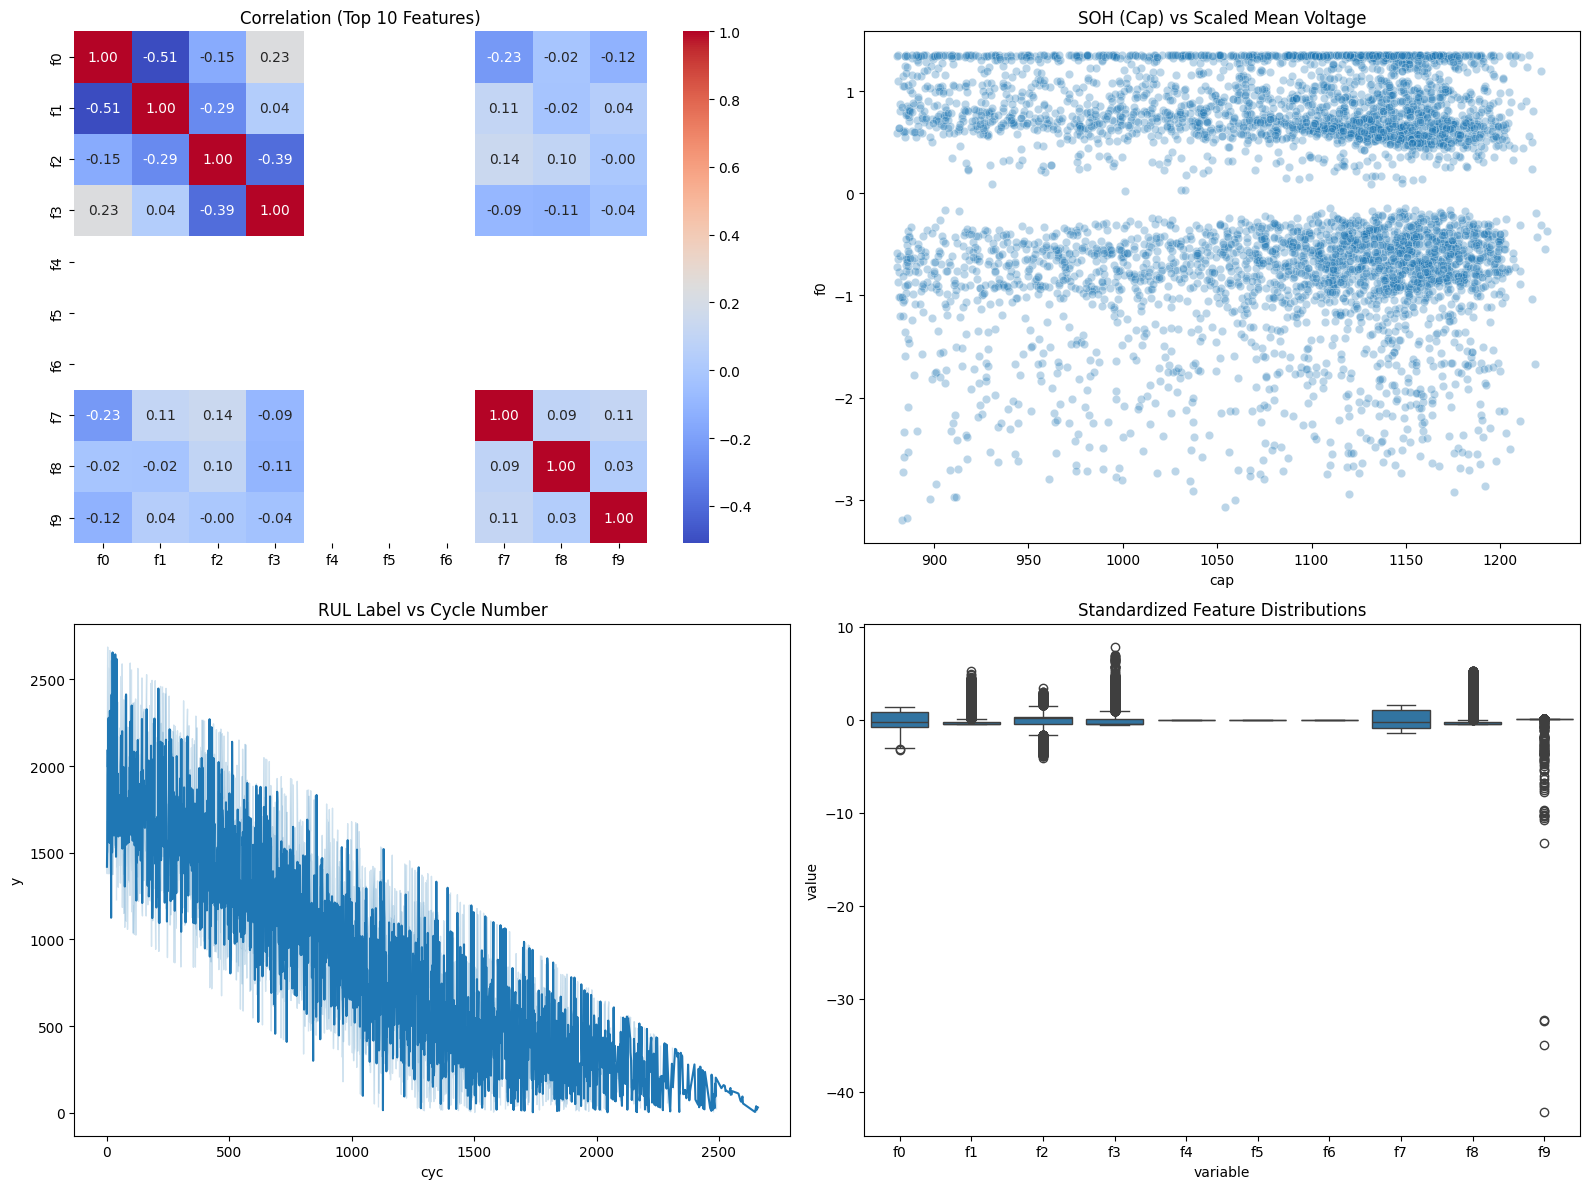

Displayed analysis for 6137124 samples from saved batches.


In [19]:
def plot_phase4_feature_analysis(pool):
    import random
    sample_pool = random.sample(pool, min(5000, len(pool)))
    df_features = pd.DataFrame([{
        "cyc": s["cyc"], "y": s["y"], "cap": s["capacity"],
        **{f"f{i}": val for i, val in enumerate(s["scaled_x"][:10])}
    } for s in sample_pool])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Correlation Matrix
    corr = df_features[[f"f{i}" for i in range(10)]].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0,0])
    axes[0,0].set_title("Correlation (Top 10 Features)")
    
    # 2. Mean Voltage (f0) vs Capacity
    sns.scatterplot(data=df_features, x='cap', y='f0', alpha=0.3, ax=axes[0,1])
    axes[0,1].set_title("SOH (Cap) vs Scaled Mean Voltage")
    
    # 3. RUL (y) Trend
    sns.lineplot(data=df_features, x='cyc', y='y', ax=axes[1,0])
    axes[1,0].set_title("RUL Label vs Cycle Number")
    
    # 4. Feature Scales
    sns.boxplot(data=df_features.melt(value_vars=[f"f{i}" for i in range(10)]), 
                x='variable', y='value', ax=axes[1,1])
    axes[1,1].set_title("Standardized Feature Distributions")
    
    plt.tight_layout()
    plt.show()

FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_feature_batches"
final_batch_files = sorted(FEATURE_BATCH_DIR.glob("final_batch_*.pkl"))

batch_feature_pool = []
if final_batch_files:
    print(f"Loading {len(final_batch_files)} final batches for analysis...")
    for bf in tqdm(final_batch_files, desc="Loading final batches"): 
        with open(bf, "rb") as f: batch_feature_pool.extend(pickle.load(f))

if 'batch_feature_pool' in locals() and len(batch_feature_pool) > 0:
    plot_phase4_feature_analysis(batch_feature_pool)
    print(f"Displayed analysis for {len(batch_feature_pool)} samples from saved batches.")
else:
    print("No data found in memory or saved batches.")

## Phase 5: Final Saving

In [20]:
if 'feature_pool' not in locals() and 'feature_pool' not in globals():
    FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{DATASET_TYPE}_feature_batches"
    batch_files = sorted(FEATURE_BATCH_DIR.glob("final_*.pkl"))
    feature_pool = []
    for bf in tqdm(batch_files, desc="Loading Final Batches"):
        with open(bf, "rb") as f: feature_pool.extend(pickle.load(f))

def save_processed_dataset(pool, dataset_type):
    out_path = PROCESSED_DATA_ROOT / f"{dataset_type}_optimized_tensors.pkl"
    final_data = []
    for item in pool:
        final_data.append({
            "cell": item['cell'], "cyc": item['cyc'], "x": item['scaled_x'],
            "soc_label": item['soc_label'], "mode_label": item['mode_label'],
            "length_p": item['length_p'], 
            "y": item.get('y', item.get('rul')),
            "capacity": item.get('capacity', 0.0)
        })
    with open(out_path, "wb") as f: pickle.dump(final_data, f)
    print(f"Saved to {out_path}")
save_processed_dataset(feature_pool, DATASET_TYPE)

Loading Final Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Saved to D:\chanminLee\data_store\LFP_SOH_estimation\hust_optimized_tensors.pkl


## Phase 6: Visualization

Loading 10 batches for visualization...


Loading batches:   0%|          | 0/10 [00:00<?, ?it/s]

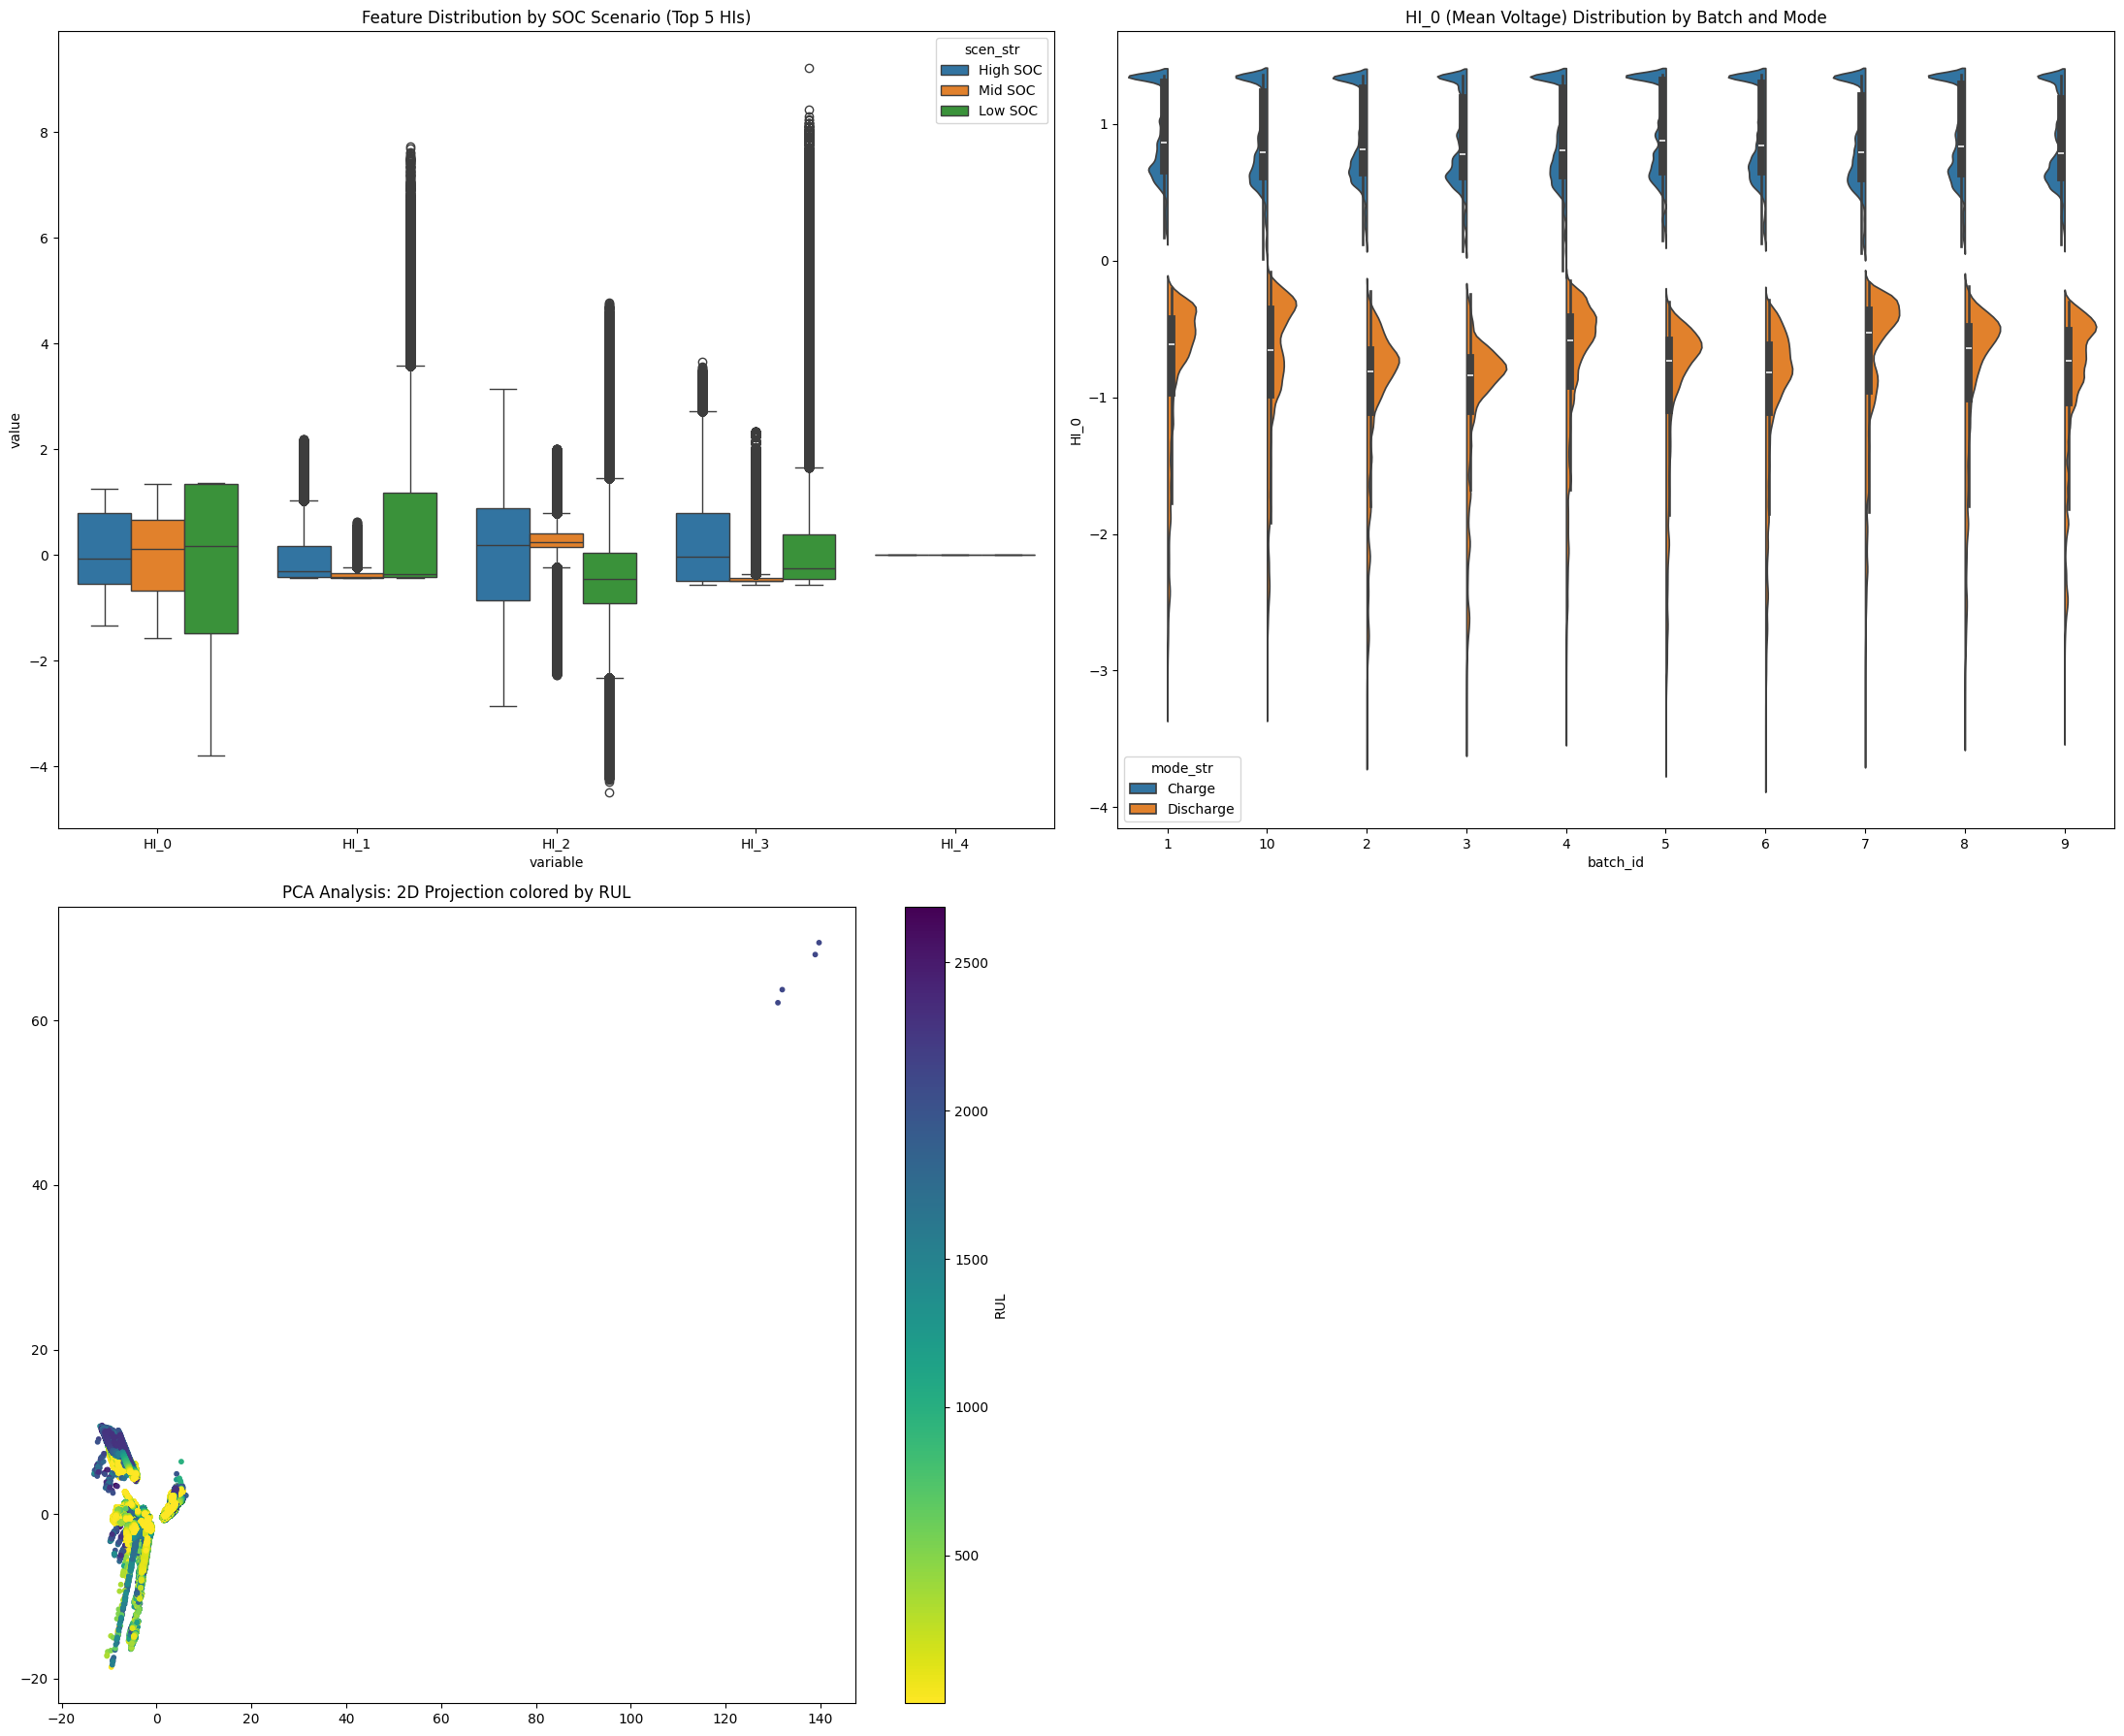

In [7]:
from sklearn.decomposition import PCA
def analyze_final_hi_dataset(dataset_type):
    FEATURE_BATCH_DIR = PROCESSED_DATA_ROOT / f"{dataset_type}_feature_batches"
    final_batch_files = sorted(FEATURE_BATCH_DIR.glob("final_batch_*.pkl"))
    
    if not final_batch_files:
        print(f"Error: No batch files found in {FEATURE_BATCH_DIR}")
        return

    all_data = []
    print(f"Loading {len(final_batch_files)} batches for visualization...")
    for bf in tqdm(final_batch_files, desc="Loading batches"): 
        with open(bf, "rb") as f: 
            batch_data = pickle.load(f)
            # Ensure consistent key naming ('scaled_x' -> 'x')
            for item in batch_data:
                if 'scaled_x' in item and 'x' not in item:
                    item['x'] = item['scaled_x']
                if 'rul' in item and 'y' not in item:
                    item['y'] = item['rul']
            all_data.extend(batch_data)
    
    if not all_data:
        print("Error: Loaded data pool is empty.")
        return

    df = pd.DataFrame(all_data)
    x_expanded = pd.DataFrame(df['x'].tolist())
    x_expanded.columns = [f"HI_{i}" for i in range(x_expanded.shape[1])]
    df = pd.concat([df.drop('x', axis=1), x_expanded], axis=1)
    
    df['batch_id'] = df['cell'].apply(lambda cid: get_batch_id(cid, dataset_type))
    df['scen_str'] = df['soc_label'].map({-2: 'High SOC', -1: 'Mid SOC', 0: 'Low SOC'})
    df['mode_str'] = df['mode_label'].map({1: 'Charge', 0: 'Discharge'})
    
    fig = plt.figure(figsize=(22, 18))
    ax1 = plt.subplot(2, 2, 1)
    # Only plot first 5 features for clarity
    sns.boxplot(data=df.melt(id_vars=['scen_str'], value_vars=[f"HI_{i}" for i in range(5)]), x='variable', y='value', hue='scen_str', ax=ax1)
    ax1.set_title("Feature Distribution by SOC Scenario (Top 5 HIs)")
    
    ax2 = plt.subplot(2, 2, 2)
    sns.violinplot(data=df, x='batch_id', y='HI_0', hue='mode_str', split=True, ax=ax2)
    ax2.set_title("HI_0 (Mean Voltage) Distribution by Batch and Mode")
    
    ax3 = plt.subplot(2, 2, 3)
    pca = PCA(n_components=2); hi_cols = [f"HI_{i}" for i in range(x_expanded.shape[1])]
    pca_res = pca.fit_transform(df[hi_cols].dropna())
    sc = plt.scatter(pca_res[:, 0], pca_res[:, 1], c=df.dropna(subset=hi_cols)['y'], cmap='viridis_r', s=10)
    plt.colorbar(sc, label='RUL')
    ax3.set_title("PCA Analysis: 2D Projection colored by RUL")
    
    plt.tight_layout()
    plt.show()
analyze_final_hi_dataset(DATASET_TYPE)